In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




##Modelo
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


###




# Raíz del proyecto
PROJECT_ROOT = Path.cwd().parents[1]

# Ruta del dataset procesado
ruta_modelo = PROJECT_ROOT / "data" / "processed" / "df_model_limpio_ndvi.csv"

print("Ruta usada:", ruta_modelo)
print("Existe:", ruta_modelo.exists())

df_model = pd.read_csv(ruta_modelo)

df_model.head()

Ruta usada: /Users/daniel/Documents/GitHub/proyecto_aplicado_en_analitica_de_datos/data/processed/df_model_limpio_ndvi.csv
Existe: True


,municipio,date,humedad_suelo_capa1,humedad_suelo_capa2,radiacion_solar_j_m2,viento_u_ms,viento_v_ms,anio,mes,temp_media_c,...,ratio_et,humedad_suelo_total,dif_temp_rocio,radiacion,presion_kpa,precip_3m,precip_6m,balance_3m,balance_6m,ndvi_mean
0,Aguadas,2005-06-01,0.437224,0.441011,1.834832e+07,-0.343014,0.085023,2005,6,18.668520,...,0.396570,0.878235,2.143487,1.834832e+07,85.044070,40.712007,66.908830,67.091950,128.162266,0.762234
1,Aguadas,2005-07-01,0.420816,0.425568,2.180335e+07,-0.477848,0.047638,2005,7,19.047603,...,0.311278,0.846384,3.532938,2.180335e+07,85.094977,36.824099,67.556962,67.748100,132.477472,0.726598
2,Aguadas,2005-08-01,0.407024,0.402045,2.107336e+07,-0.450713,0.086187,2005,8,19.217334,...,0.287248,0.809069,3.667424,2.107336e+07,85.059730,27.585174,69.953348,62.926250,135.883264,0.690933
3,Aguadas,2005-09-01,0.420713,0.420046,2.151291e+07,-0.308786,0.122309,2005,9,19.621358,...,0.283769,0.840759,3.897556,2.151291e+07,85.048246,24.075726,64.787733,64.720724,131.812674,0.690747
4,Aguadas,2005-10-01,0.442982,0.445658,1.609550e+07,0.008002,0.139188,2005,10,18.178844,...,0.434752,0.888641,1.797782,1.609550e+07,85.101348,35.530332,72.354431,69.798604,137.546704,0.582663


# Analisis variables Modelo 

## Analisis NDVI

In [2]:
df_model["ndvi_mean"].describe()

count    6642.000000
mean        0.679636
std         0.103057
min         0.130342
25%         0.629397
50%         0.706302
75%         0.753297
max         0.854509
Name: ndvi_mean, dtype: float64

### Histograma NDVI

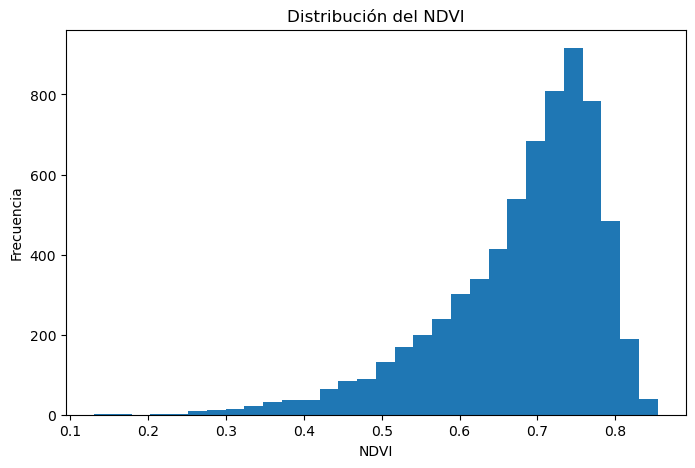

In [3]:
plt.figure(figsize=(8,5))

plt.hist(df_model["ndvi_mean"], bins=30)

plt.xlabel("NDVI")
plt.ylabel("Frecuencia")
plt.title("Distribución del NDVI")

plt.show()

### Boxplot NDVI

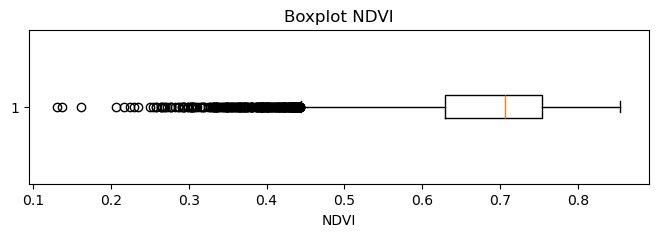

In [5]:
plt.figure(figsize=(8,2))

plt.boxplot(df_model["ndvi_mean"], vert=False)

plt.xlabel("NDVI")
plt.title("Boxplot NDVI")

plt.show()

### Serie temporal anual promedio NDVI

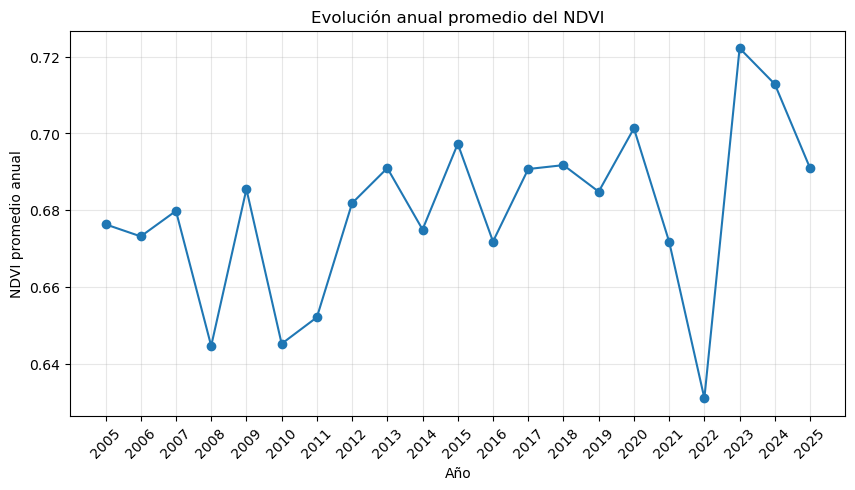

In [7]:
# NDVI promedio anual
ndvi_anual = (
    df_model.groupby("anio")["ndvi_mean"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    ndvi_anual["anio"],
    ndvi_anual["ndvi_mean"],
    marker="o"
)

plt.xlabel("Año")
plt.ylabel("NDVI promedio anual")
plt.title("Evolución anual promedio del NDVI")
plt.xticks(ndvi_anual["anio"], rotation=45)
plt.grid(alpha=0.3)

plt.show()

### estacionalidad NDVI mensual

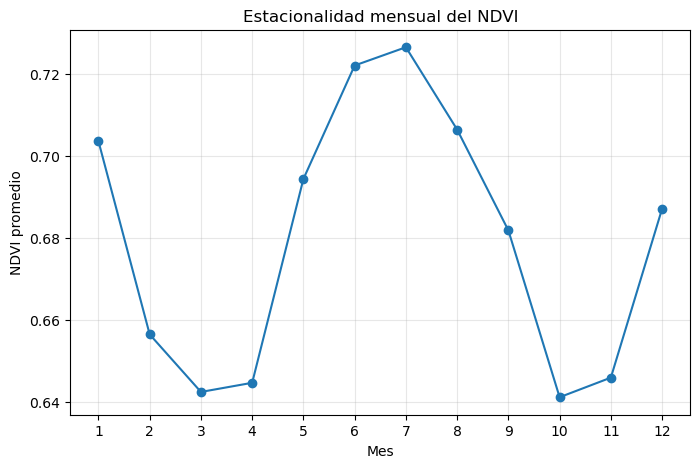

In [9]:
ndvi_mes = (
    df_model.groupby("mes")["ndvi_mean"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    ndvi_mes["mes"],
    ndvi_mes["ndvi_mean"],
    marker="o"
)

plt.xlabel("Mes")
plt.ylabel("NDVI promedio")
plt.title("Estacionalidad mensual del NDVI")

plt.xticks(range(1,13))
plt.grid(alpha=0.3)

plt.show()

## Matriz de correlación con la variable objetivo

In [11]:
# Seleccionar solo variables numéricas
df_num = df_model.select_dtypes(include="number").copy()

# Correlación de todas las variables numéricas con NDVI
corr_ndvi = (
    df_num
    .corr(method="spearman")["ndvi_mean"]
    .sort_values(ascending=False)
)

corr_ndvi

ndvi_mean               1.000000
temp_media_c            0.474764
presion_kpa             0.451381
temp_max_c              0.449702
temp_min_c              0.427402
temp_rocio_c            0.332954
viento_u_ms             0.280628
dif_temp_rocio          0.174384
amplitud_termica_c      0.156822
balance_3m              0.142731
radiacion               0.141430
radiacion_solar_j_m2    0.141430
balance_6m              0.139020
anio                    0.094543
balance_hidrico_mm      0.058118
velocidad_viento_ms     0.003067
mes                    -0.000667
deficit_hidrico_mm     -0.058118
et_real_mm             -0.073575
precip_3m              -0.087142
precip_6m              -0.096424
viento_v_ms            -0.110654
escorrentia_sup_mm     -0.128804
precip_mm              -0.181939
escorrentia_sub_mm     -0.221608
ratio_et               -0.280256
et_potencial_mm        -0.287941
humedad_suelo_capa1    -0.303889
humedad_suelo_total    -0.313012
humedad_suelo_capa2    -0.321431
estres_hid

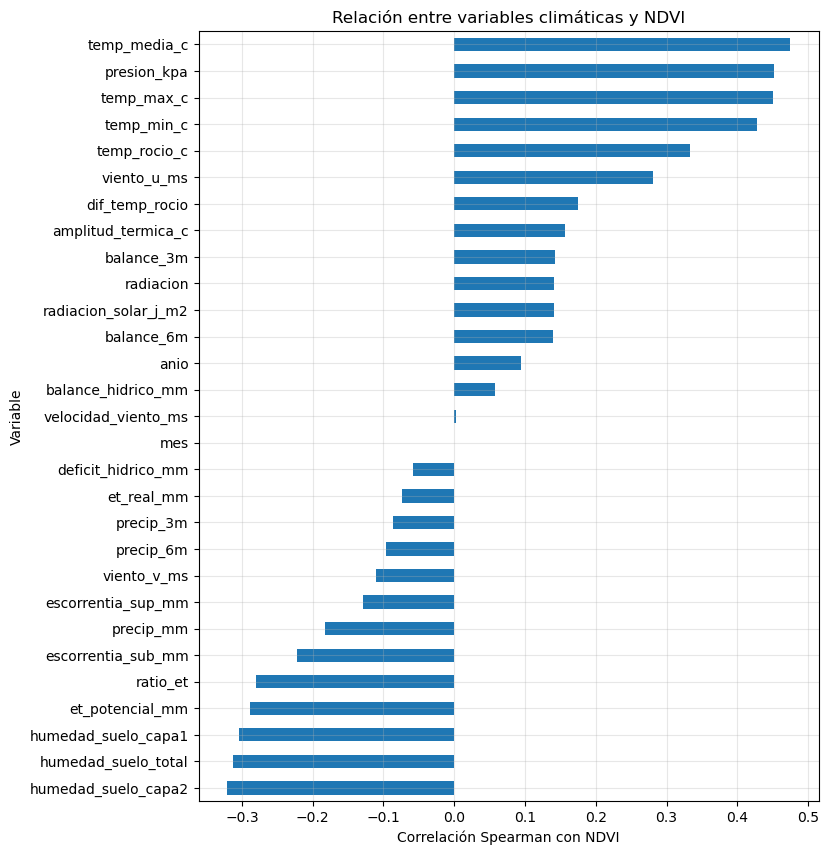

In [12]:

# Quitar ndvi_mean y valores NaN
corr_plot = corr_ndvi.drop(labels=["ndvi_mean"], errors="ignore").dropna()

plt.figure(figsize=(8, 10))

corr_plot.sort_values().plot(kind="barh")

plt.xlabel("Correlación Spearman con NDVI")
plt.ylabel("Variable")
plt.title("Relación entre variables climáticas y NDVI")
plt.grid(alpha=0.3)

plt.show()

La correlación entre las variables climáticas y el NDVI muestra que las variables relacionadas con temperatura presentan una relación positiva con el comportamiento de la vegetación. En general, valores más altos de temperatura se asocian con mayores niveles de NDVI, reflejando un mejor estado del cultivo.

Por otro lado, variables relacionadas con precipitación, humedad y escorrentía presentan relaciones negativas con el NDVI. Esto puede indicar que periodos de exceso de humedad o lluvias intensas también afectan el comportamiento de la vegetación.

En conjunto, los resultados muestran que el NDVI responde a cambios en las condiciones climáticas

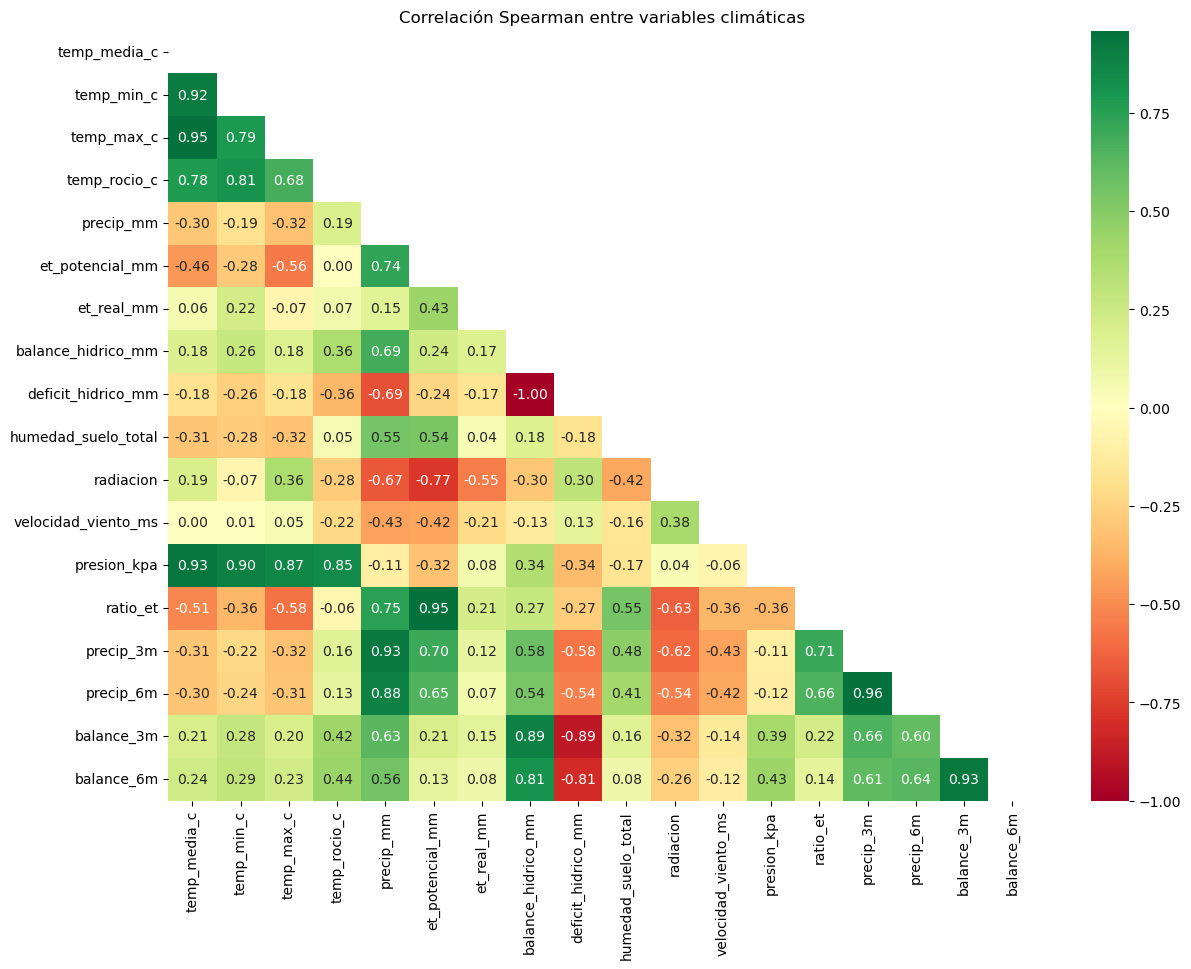

In [14]:
# Variables climáticas
cols_corr = [
    "temp_media_c",
    "temp_min_c",
    "temp_max_c",
    "temp_rocio_c",
    "precip_mm",
    "et_potencial_mm",
    "et_real_mm",
    "balance_hidrico_mm",
    "deficit_hidrico_mm",
    "humedad_suelo_total",
    "radiacion",
    "velocidad_viento_ms",
    "presion_kpa",
    "ratio_et",
    "precip_3m",
    "precip_6m",
    "balance_3m",
    "balance_6m"
]

# Matriz
corr_matrix = df_model[cols_corr].corr(method="spearman")

# Máscara triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Figura
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdYlGn",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlación Spearman entre variables climáticas")

plt.show()

#### Consulta Variables altamente correlacionadas 

In [15]:
# Buscar pares altamente correlacionados
threshold = 0.85

pares_altos = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        
        rho = corr_matrix.iloc[i, j]
        
        if abs(rho) > threshold:
            
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            
            pares_altos.append((col1, col2, round(rho, 3)))

# Mostrar resultados
print("Pares altamente correlacionados:\n")

for par in pares_altos:
    print(par)

Pares altamente correlacionados:

('temp_min_c', 'temp_media_c', np.float64(0.916))
('temp_max_c', 'temp_media_c', np.float64(0.953))
('deficit_hidrico_mm', 'balance_hidrico_mm', np.float64(-1.0))
('presion_kpa', 'temp_media_c', np.float64(0.929))
('presion_kpa', 'temp_min_c', np.float64(0.896))
('presion_kpa', 'temp_max_c', np.float64(0.872))
('ratio_et', 'et_potencial_mm', np.float64(0.952))
('precip_3m', 'precip_mm', np.float64(0.926))
('precip_6m', 'precip_mm', np.float64(0.884))
('precip_6m', 'precip_3m', np.float64(0.959))
('balance_3m', 'balance_hidrico_mm', np.float64(0.89))
('balance_3m', 'deficit_hidrico_mm', np.float64(-0.89))
('balance_6m', 'balance_3m', np.float64(0.927))


Los resultados sugieren la presencia de redundancia en algunas variables, por lo que posteriormente se evaluarán dos escenarios de modelado: uno utilizando el conjunto completo de variables y otro utilizando una versión depurada con menor multicolinealidad. Esto permitirá comparar el desempeño de ambos enfoques y seleccionar la configuración más adecuada para el modelo final.

# Modelo

## Split temporal 

El conjunto de datos se dividira utilizando un enfoque de serie temporal, evitando el uso de particiones aleatorias (shuffle). Esta decisión se tomó para preservar la secuencia cronológica de la información y evitar problemas de data leakage, donde el modelo podría acceder indirectamente a información futura durante el entrenamiento.


In [16]:
# Asegurar orden temporal
df_model = df_model.sort_values("date").copy()

# Fechas mensuales únicas
fechas_unicas = sorted(df_model["date"].unique())

n_fechas = len(fechas_unicas)

# Porcentajes definidos
pct_train = 0.70
pct_val = 0.10
pct_test = 0.20

# Puntos de corte
n_train = int(n_fechas * pct_train)
n_val = int(n_fechas * pct_val)

fecha_train_end = fechas_unicas[n_train - 1]
fecha_val_end = fechas_unicas[n_train + n_val - 1]

print("Total fechas mensuales:", n_fechas)
print("Fechas train:", n_train)
print("Fechas val:", n_val)
print("Fechas test:", n_fechas - n_train - n_val)

print("\nCortes temporales:")
print("Train hasta:", fecha_train_end)
print("Val hasta:", fecha_val_end)
print("Test desde:", fechas_unicas[n_train + n_val])

Total fechas mensuales: 246
Fechas train: 172
Fechas val: 24
Fechas test: 50

Cortes temporales:
Train hasta: 2019-09-01
Val hasta: 2021-09-01
Test desde: 2021-10-01


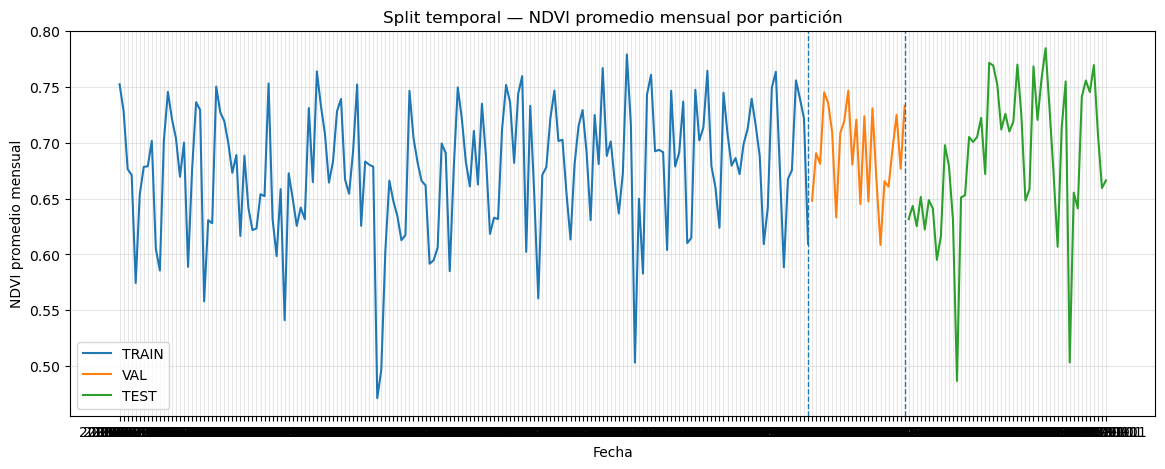

In [21]:
# NDVI promedio mensual por partición
ndvi_train = df_train.groupby("date")["ndvi_mean"].mean().reset_index()
ndvi_val = df_val.groupby("date")["ndvi_mean"].mean().reset_index()
ndvi_test = df_test.groupby("date")["ndvi_mean"].mean().reset_index()

plt.figure(figsize=(14,5))

plt.plot(ndvi_train["date"], ndvi_train["ndvi_mean"], label="TRAIN")
plt.plot(ndvi_val["date"], ndvi_val["ndvi_mean"], label="VAL")
plt.plot(ndvi_test["date"], ndvi_test["ndvi_mean"], label="TEST")

plt.axvline(fecha_train_end, linestyle="--", linewidth=1)
plt.axvline(fecha_val_end, linestyle="--", linewidth=1)

plt.xlabel("Fecha")
plt.ylabel("NDVI promedio mensual")
plt.title("Split temporal — NDVI promedio mensual por partición")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

La partición temporal se definió siguiendo un enfoque hold-out cronológico, ampliamente utilizado en problemas de series temporales y modelado climático. Se reservó el periodo más reciente para evaluación final, permitiendo simular un escenario real de predicción sobre datos futuros no observados durante el entrenamiento.

In [17]:
# Crear particiones temporales
df_train = df_model[df_model["date"] <= fecha_train_end].copy()

df_val = df_model[
    (df_model["date"] > fecha_train_end) &
    (df_model["date"] <= fecha_val_end)
].copy()

df_test = df_model[df_model["date"] > fecha_val_end].copy()

# Validación de particiones
for nombre, df_part in [
    ("TRAIN", df_train),
    ("VAL", df_val),
    ("TEST", df_test)
]:
    print(f"\n--- {nombre} ---")
    print("Rango:", df_part["date"].min(), "→", df_part["date"].max())
    print("Filas:", len(df_part))
    print("% registros:", round(len(df_part) / len(df_model) * 100, 2))
    print("Municipios:", df_part["municipio"].nunique())


--- TRAIN ---
Rango: 2005-06-01 → 2019-09-01
Filas: 4644
% registros: 69.92
Municipios: 27

--- VAL ---
Rango: 2019-10-01 → 2021-09-01
Filas: 648
% registros: 9.76
Municipios: 27

--- TEST ---
Rango: 2021-10-01 → 2025-11-01
Filas: 1350
% registros: 20.33
Municipios: 27


## Definición de variables 

In [19]:
# Variable objetivo
target = "ndvi_mean"

# Columnas que no deben entrar como variables explicativas
cols_no_modelo = [
    "ndvi_mean",
    "date"
]

# Escenario A: variables completas
X_train_full = df_train.drop(columns=cols_no_modelo)
X_val_full   = df_val.drop(columns=cols_no_modelo)
X_test_full  = df_test.drop(columns=cols_no_modelo)

y_train = df_train[target]
y_val   = df_val[target]
y_test  = df_test[target]

print("X_train_full:", X_train_full.shape)
print("X_val_full:", X_val_full.shape)
print("X_test_full:", X_test_full.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train_full: (4644, 31)
X_val_full: (648, 31)
X_test_full: (1350, 31)
y_train: (4644,)
y_val: (648,)
y_test: (1350,)


## Codificar Variable Municipio 

In [20]:
# Codificación de la variable municipio
X_train_full_enc = pd.get_dummies(X_train_full, columns=["municipio"], drop_first=True)
X_val_full_enc   = pd.get_dummies(X_val_full, columns=["municipio"], drop_first=True)
X_test_full_enc  = pd.get_dummies(X_test_full, columns=["municipio"], drop_first=True)

# Alinear columnas entre train, val y test
X_val_full_enc = X_val_full_enc.reindex(columns=X_train_full_enc.columns, fill_value=0)
X_test_full_enc = X_test_full_enc.reindex(columns=X_train_full_enc.columns, fill_value=0)

print("X_train_full_enc:", X_train_full_enc.shape)
print("X_val_full_enc:", X_val_full_enc.shape)
print("X_test_full_enc:", X_test_full_enc.shape)

X_train_full_enc: (4644, 56)
X_val_full_enc: (648, 56)
X_test_full_enc: (1350, 56)


La variable municipio se codificó para permitir que el modelo capture diferencias espaciales entre territorios. 


## Funcion para evaluar modelos 

In [27]:

def evaluar_modelo(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    print(f"=== {nombre} ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    # Real vs predicho
    plt.figure(figsize=(6,5))
    plt.scatter(y_real, y_pred, alpha=0.5)
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], linestyle="--")
    plt.xlabel("NDVI real")
    plt.ylabel("NDVI predicho")
    plt.title(f"{nombre} - Real vs Predicho")
    plt.grid(alpha=0.3)
    plt.show()

    # Residuos
    residuos = y_real - y_pred

    plt.figure(figsize=(7,4))
    plt.hist(residuos, bins=30)
    plt.xlabel("Error residual")
    plt.ylabel("Frecuencia")
    plt.title(f"{nombre} - Distribución de residuos")
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Modelo Regresión Ridge

Mejores parámetros: {'model__alpha': 1}
Mejor RMSE CV: 0.0686
=== Ridge optimizado ===
MAE : 0.0449
RMSE: 0.0582
R2  : 0.6425


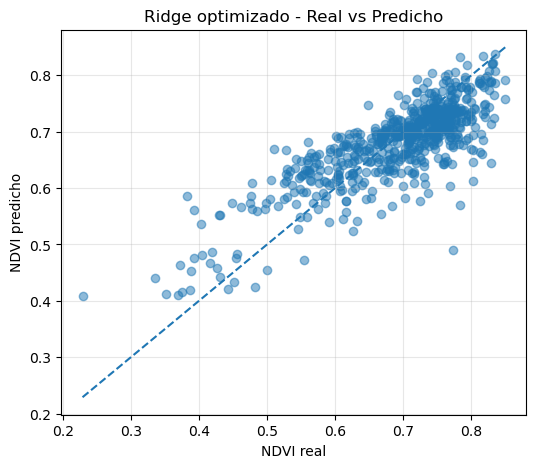

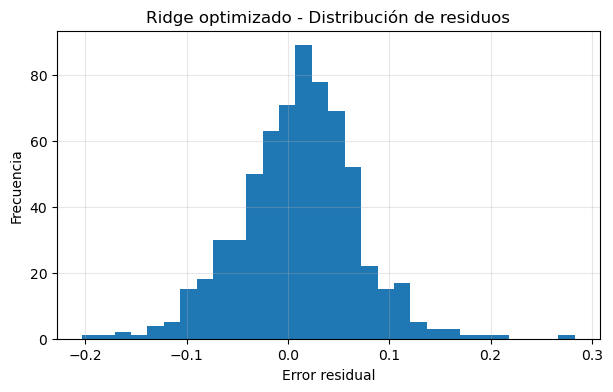

In [29]:
# Pipeline Ridge
ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# Grilla de alpha
param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

# Validación temporal dentro de train
tscv = TimeSeriesSplit(n_splits=5)

grid_ridge = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

grid_ridge.fit(X_train_full_enc, y_train)

print("Mejores parámetros:", grid_ridge.best_params_)
print("Mejor RMSE CV:", round(-grid_ridge.best_score_, 4))

# Evaluar mejor Ridge en validación
best_ridge = grid_ridge.best_estimator_
y_val_pred_ridge_opt = best_ridge.predict(X_val_full_enc)

resultado_ridge_opt = evaluar_modelo(
    "Ridge optimizado",
    y_val,
    y_val_pred_ridge_opt
)

## Modelo Random Forest

=== Random Forest ===
MAE : 0.0485
RMSE: 0.0622
R2  : 0.5925


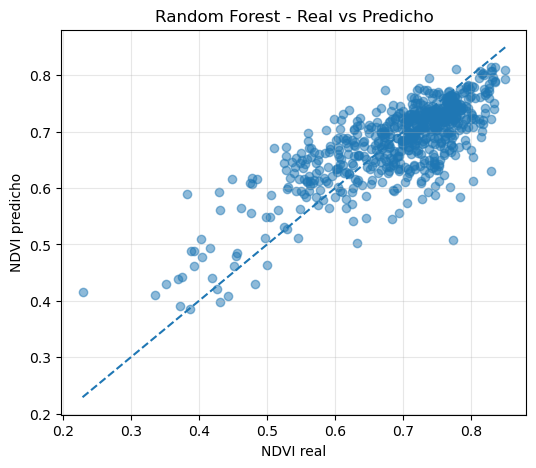

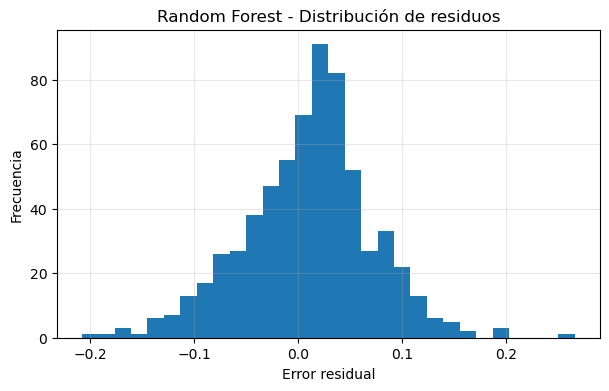

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Modelo Random Forest base
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Entrenar
rf_model.fit(X_train_full_enc, y_train)

# Predecir validación
y_val_pred_rf = rf_model.predict(X_val_full_enc)

# Evaluar
resultado_rf = evaluar_modelo(
    "Random Forest",
    y_val,
    y_val_pred_rf
)

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=5)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_full_enc, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor RMSE CV:", round(-grid_rf.best_score_, 4))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
